# Workflow without llm

In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [3]:
class bmi_state(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    label_bmi : str

In [4]:
graph = StateGraph(state_schema=bmi_state)

In [5]:
def calculate_bmi(state:bmi_state)->bmi_state:
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight / (height ** 2)

    state['bmi']= bmi

    return state

In [6]:
def label_bmi(state:bmi_state)->bmi_state:
    bmi = state['bmi']
    if bmi < 18.5:
        state["label_bmi"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["label_bmi"] = "Normal"
    elif 25 <= bmi < 30:
        state["label_bmi"] = "Overweight"
    else:
        state["label_bmi"] = "Obese"
    
    return state

In [7]:
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('label_bmi',label_bmi)

graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label_bmi')
graph.add_edge('label_bmi',END)

workflow = graph.compile()

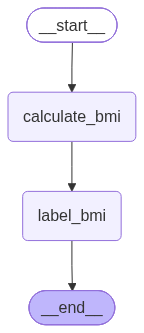

In [8]:
workflow

In [9]:
workflow.invoke(input = {
    'weight_kg':62,
    'height_m':1.74
})

{'weight_kg': 62,
 'height_m': 1.74,
 'bmi': 20.478266613819528,
 'label_bmi': 'Normal'}

# workflow with llm

In [12]:
from dotenv import load_dotenv
load_dotenv()

True

In [10]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [13]:
class chatState(TypedDict):
    question : str 
    answer : str

In [14]:
graph = StateGraph(state_schema=chatState)

In [15]:
llm = ChatOpenAI(model = 'gpt-4o-mini')

In [17]:
def call_llm(state:chatState)->chatState:
    question = state['question']
    response = llm.invoke(f"answer the following question {question}")

    state['answer'] = response.content

    return state
    

In [18]:
graph.add_node('call llm',call_llm)
graph.add_edge(START,'call llm')
graph.add_edge('call llm',END)

workflow = graph.compile()

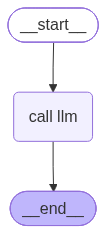

In [19]:
workflow

In [20]:
workflow.invoke(input={
    'question':'what is the difference between genai and the agentic ai'
})

{'question': 'what is the difference between genai and the agentic ai',
 'answer': "Generative AI (GenAI) and agentic AI refer to two distinct concepts within the broader field of artificial intelligence, each with different functionalities and applications.\n\n### Generative AI (GenAI)\n- **Definition**: GenAI refers to AI systems designed to generate content, such as text, images, music, or other media. These models can create new data based on the patterns they've learned from training data.\n- **Examples**: Models like OpenAI's GPT (for text generation), DALL-E (for image generation), or music generation systems.\n- **Purpose**: The primary purpose of GenAI is to produce creative outputs or simulate human-like responses by understanding and replicating the nuances of human expression.\n- **Operation**: GenAI relies on training on large datasets to learn patterns and structures, which it then uses to generate new content that resembles the training data.\n\n### Agentic AI\n- **Defin

# workflow with Chains

In [21]:
from dotenv import load_dotenv
load_dotenv()

True

In [22]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict

In [23]:
class BlogState(TypedDict):
    title : str
    outline : str
    content : str
    rating : float

In [24]:
graph = StateGraph(state_schema=BlogState)

In [25]:

model = ChatOpenAI()

In [26]:
def generate_outline(state:BlogState)->BlogState:
    title = state['title']
    prompt = f'generate the detailed outline about the topic {title} which is helpful to write the blog content'
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

In [27]:
def generate_content(state:BlogState)->BlogState:
    title = state['title']
    outline = state['outline']
    prompt=f'write a detailed blog on the topic {title} with this outline\n{outline}'
    content = model.invoke(prompt).content
    state['content'] = content
    return state

In [28]:
def evaluate_content(state:BlogState)->BlogState:
    title = state['title']
    content = state['content']
    prompt = f'rate the following blog content {content} for the topic {title} out of 10.'    
    rating = model.invoke(prompt).content
    state['rating'] = rating
    return state

In [29]:
graph.add_node('generate_outline',generate_outline)
graph.add_node('generate_content',generate_content)
graph.add_node('evaluate_content',evaluate_content)

graph.add_edge(START,'generate_outline')
graph.add_edge('generate_outline','generate_content')
graph.add_edge('generate_content','evaluate_content')
graph.add_edge('evaluate_content',END)

workflow = graph.compile()

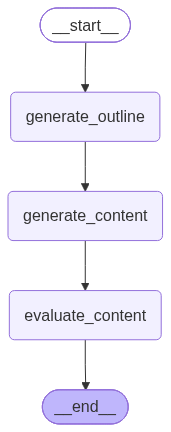

In [30]:
workflow

In [32]:
result = workflow.invoke(input ={
    'title':'agentic ai engineer'
})

In [34]:
type(result)

dict

In [35]:
result['title']

'agentic ai engineer'

In [36]:
result['outline']

'I. Introduction\nA. Definition of an agentic AI engineer\nB. Importance of agentic AI engineers in the field of artificial intelligence\nC. Purpose of blog post\n\nII. Skills and Qualifications of an Agentic AI Engineer\nA. Technical skills required\n1. Knowledge of machine learning algorithms\n2. Proficiency in programming languages such as Python, R, Java\n3. Experience with data analysis and visualization tools\nB. Soft skills needed\n1. Problem-solving abilities\n2. Teamwork and collaboration\n3. Strong communication skills\n\nIII. Responsibilities of an Agentic AI Engineer\nA. Developing and implementing AI solutions\nB. Collaborating with cross-functional teams to understand business requirements\nC. Monitoring and maintaining AI systems\nD. Ensuring data privacy and security in AI applications\n\nIV. Challenges Faced by Agentic AI Engineers\nA. Ethical considerations in AI development\nB. Ensuring transparency and accountability in AI algorithms\nC. Managing biases in AI system

In [37]:
result['content']

'\n\nI. Introduction\n\nA. An agentic AI engineer is a professional who possesses both technical expertise in artificial intelligence and the ability to take initiative and work independently to solve complex problems. These individuals play a crucial role in developing and implementing AI solutions that drive innovation and efficiency in various industries.\n\nB. As artificial intelligence continues to transform businesses and societies, the demand for agentic AI engineers is on the rise. These professionals are essential for designing and optimizing AI systems that can analyze data, automate processes, and make intelligent decisions.\n\nC. The purpose of this blog post is to explore the skills, responsibilities, challenges, and career opportunities of agentic AI engineers. By understanding the importance of these professionals, aspiring AI engineers can gain insights into what it takes to succeed in this dynamic and rewarding field.\n\nII. Skills and Qualifications of an Agentic AI E

In [38]:
result['rating']

'I would rate this blog content a 8 out of 10 for the topic of agentic AI engineer. The content provides a comprehensive overview of the role, skills, responsibilities, challenges, and career opportunities of agentic AI engineers. It covers all the essential aspects of the topic in a clear and structured manner. The information is relevant and informative for individuals looking to pursue a career in AI engineering. The conclusion ties everything together nicely and provides valuable insights for aspiring AI engineers. Overall, the content is well-written and engaging.'